In [14]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
from sklearn.decomposition import PCA

In [15]:
# Importação da base de dados
df = pd.read_csv('../csv/student-mat.csv', sep=';') #Leitura do csv separado por ;
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [16]:
# Verificar valores ausentes
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [17]:
# Total de valores ausentes
df.isnull().sum().sum()

np.int64(0)

In [18]:
# Verificação de valores duplicados
df.duplicated().sum()

np.int64(0)

In [19]:
# Esclusão de valores duplicados
df = df.drop_duplicates()

In [20]:
# Identificação de possíveis outliers

colunas_numericas = df.select_dtypes(include=np.number).columns

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - (1.5 * IQR)
    limite_sup = Q3 + (1.5 * IQR)

    qtd = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()

    print(f'{col}: {qtd}')

age: 1
Medu: 0
Fedu: 2
traveltime: 8
studytime: 27
failures: 83
famrel: 26
freetime: 19
goout: 0
Dalc: 18
Walc: 0
health: 0
absences: 15
G1: 0
G2: 13
G3: 0


In [21]:
# Atributos categóricos

# Binários
binarias = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

df_processado = pd.get_dummies(df, columns=binarias, drop_first=True, dtype=int)

# Nominais

nominais = ['Mjob', 'Fjob', 'reason', 'guardian']

label_encoders = {}
# 3. Aplica o Label Encoding coluna por coluna
for coluna in nominais:
    le = LabelEncoder()
    # Ajusta o encoder e transforma a coluna substituindo os valores originais
    df[coluna] = le.fit_transform(df_processado[coluna])
    # Guarda o encoder treinado caso precise decodificar os números mais tarde
    label_encoders[coluna] = le

In [22]:
df_processado.head()

,age,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,...,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,at_home,teacher,course,mother,2,2,0,...,0,0,1,0,0,0,1,1,0,0
1,17,1,1,at_home,other,course,father,1,2,0,...,0,1,0,1,0,0,0,1,1,0
2,15,1,1,at_home,other,other,mother,1,2,3,...,1,1,1,0,1,0,1,1,1,0
3,15,4,2,health,services,home,mother,1,3,0,...,0,1,0,1,1,1,1,1,1,1
4,16,3,3,other,other,home,father,1,2,0,...,0,1,0,1,1,0,1,1,0,0


In [23]:
# Atributos para agrupamento: Perfil acadêmico

atributos_cluster = [
    'studytime',
    'failures',
    'absences',
    'G1',
    'G2',
    'G3'
]

X = df_processado[atributos_cluster]

# Padronização dos dados

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Tabela com os dados padronizados
X_scaled_df = pd.DataFrame(X_scaled, columns=atributos_cluster)
X_scaled_df.head()

,studytime,failures,absences,G1,G2,G3
0,0.333333,0.0,0.080000,0.1250,0.315789,0.30
1,0.333333,0.0,0.053333,0.1250,0.263158,0.30
2,0.333333,1.0,0.133333,0.2500,0.421053,0.50
3,0.666667,0.0,0.026667,0.7500,0.736842,0.75
4,0.333333,0.0,0.053333,0.1875,0.526316,0.50


In [24]:
print("Matriz de Distâncias Euclidianas:")
print(euclidean_distances(X_scaled))

Matriz de Distâncias Euclidianas:
[[0.         0.05900165 1.0341904  ... 1.1063217  0.63076073 0.4403134 ]
 [0.05900165 0.         1.0425717  ... 1.11192441 0.65598371 0.46180783]
 [1.0341904  1.0425717  0.         ... 0.42128194 1.11162504 1.06053378]
 ...
 [1.1063217  1.11192441 0.42128194 ... 0.         1.03553251 1.01444871]
 [0.63076073 0.65598371 1.11162504 ... 1.03553251 0.         0.25890431]
 [0.4403134  0.46180783 1.06053378 ... 1.01444871 0.25890431 0.        ]]


In [25]:
# Utilização inicial do K-Means para agrupamento

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df_processado['grupo'] = kmeans.labels_
print(df_processado)
# df_processado.to_csv('../csv/student-mat-processado.csv', index=False)


     age  Medu  Fedu      Mjob      Fjob  reason guardian  traveltime  \
0     18     4     4   at_home   teacher  course   mother           2   
1     17     1     1   at_home     other  course   father           1   
2     15     1     1   at_home     other   other   mother           1   
3     15     4     2    health  services    home   mother           1   
4     16     3     3     other     other    home   father           1   
..   ...   ...   ...       ...       ...     ...      ...         ...   
390   20     2     2  services  services  course    other           1   
391   17     3     1  services  services  course   mother           2   
392   21     1     1     other     other  course    other           1   
393   18     3     2  services     other  course   mother           3   
394   19     1     1     other   at_home  course   father           1   

     studytime  failures  ...  Pstatus_T  schoolsup_yes  famsup_yes  paid_yes  \
0            2         0  ...          0  

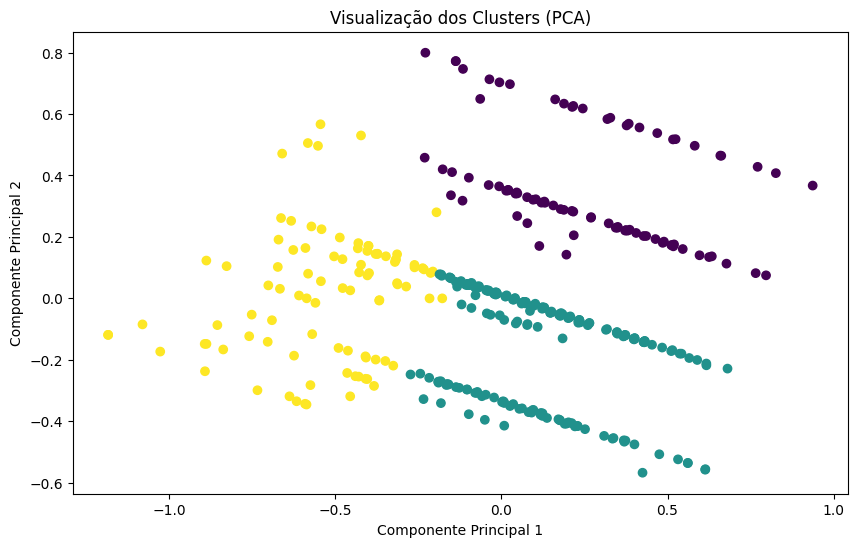

In [26]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualização dos Clusters (PCA)')

plt.show()